In [8]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yazidabdelmonem","key":"43f80859046303f8ac82cc6a9b4956c0"}'}

In [38]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset from Kaggle
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Unzip dataset
!unzip new-plant-diseases-dataset.zip -d /content/Plant_Disease_Dataset


Streaming output truncated to the last 5000 lines.
  inflating: /content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: /content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: /content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: /content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: /content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(A


## **About Dataset**


#### Dataset Link from kaggle : https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

This dataset is recreated using offline augmentation from the original dataset. The original dataset can be found on this github repo. This dataset consists of about 87K rgb images of healthy and diseased crop leaves which is categorized into 38 different classes. The total dataset is divided into 80/20 ratio of training and validation set preserving the directory structure. A new directory containing 33 test images is created later for prediction purpose.

**The Plant Village Dataset is ideal for data mining applications for several key reasons:**

1) It presents a complex multi-class classification problem (38 plant-disease pairs) that demonstrates advanced pattern recognition techniques
2) Image data requires sophisticated preprocessing and feature extraction, showcasing core data mining concepts like dimensionality reduction and feature engineering
3) The visual patterns of plant diseases (spots, discoloration, wilting) provide perfect opportunities to apply computer vision techniques within a data mining framework
4) The project addresses a significant real-world problem - plant diseases cost the global economy $220 billion annually and threaten food security
5) The resulting model has immediate practical applications in agricultural technology, allowing farmers to detect diseases early, reduce crop losses, minimize chemical usage, and implement sustainable farming practices

In [39]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import os
import glob as gb
import glob
import cv2

### Description of the dataset
dataset_path = 'data_mining_yazid_houdayfa/Plant_Disease_Dataset'

### Semantic meaning of features:
 - The dataset contains images of plant leaves.
 - Features include the RGB pixel values of the images.
 - Labels represent the class of the plant disease or healthy plant.

### Types of data:
 - Image data (numerical, RGB pixel values).
 - Labels (categorical, representing 38 classes).

### Challenges in handling the dataset:
 1. Class imbalance: Some classes may have significantly more images than others.
 2. No missing values in image datasets, but corrupted or unreadable images might exist.



## Data Preprocessing

### Training Image Preprocessing

In [40]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [41]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


### Testing Image Preprocessing

In [42]:
testing_set = tf.keras.utils.image_dataset_from_directory(
    '/content/Plant_Disease_Dataset/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 33 files belonging to 1 classes.


In [43]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [44]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[145.25 125.25 116.25]
   [139.   119.   110.  ]
   [126.5  106.5   97.5 ]
   ...
   [140.75 117.75 109.75]
   [134.75 111.75 103.75]
   [130.5  107.5   99.5 ]]

  [[139.5  119.5  110.5 ]
   [126.5  106.5   97.5 ]
   [135.   115.   106.  ]
   ...
   [144.5  121.5  113.5 ]
   [133.   110.   102.  ]
   [119.25  96.25  88.25]]

  [[135.75 115.75 106.75]
   [157.   137.   128.  ]
   [136.5  116.5  107.5 ]
   ...
   [150.75 127.75 119.75]
   [117.5   94.5   86.5 ]
   [132.   109.   101.  ]]

  ...

  [[174.25 161.25 155.25]
   [174.25 161.25 155.25]
   [176.75 163.75 157.75]
   ...
   [181.75 168.75 160.75]
   [184.25 171.25 163.25]
   [187.   174.   166.  ]]

  [[174.   161.   155.  ]
   [169.5  156.5  150.5 ]
   [168.5  155.5  149.5 ]
   ...
   [191.25 178.25 170.25]
   [188.5  175.5  167.5 ]
   [188.   175.   167.  ]]

  [[167.5  154.5  148.5 ]
   [173.5  160.5  154.5 ]
   [173.75 160.75 154.75]
   ...
   [189.25 176.25 168.25]
   [184.75 171.75 163.75]
   [190.   177.   16

## Exploratory Data Analysis (EDA)


In [17]:
# To get class indices, map class names to their indices
class_indices_training = {class_name: idx for idx, class_name in enumerate(training_set.class_names)}
print(class_indices_training)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

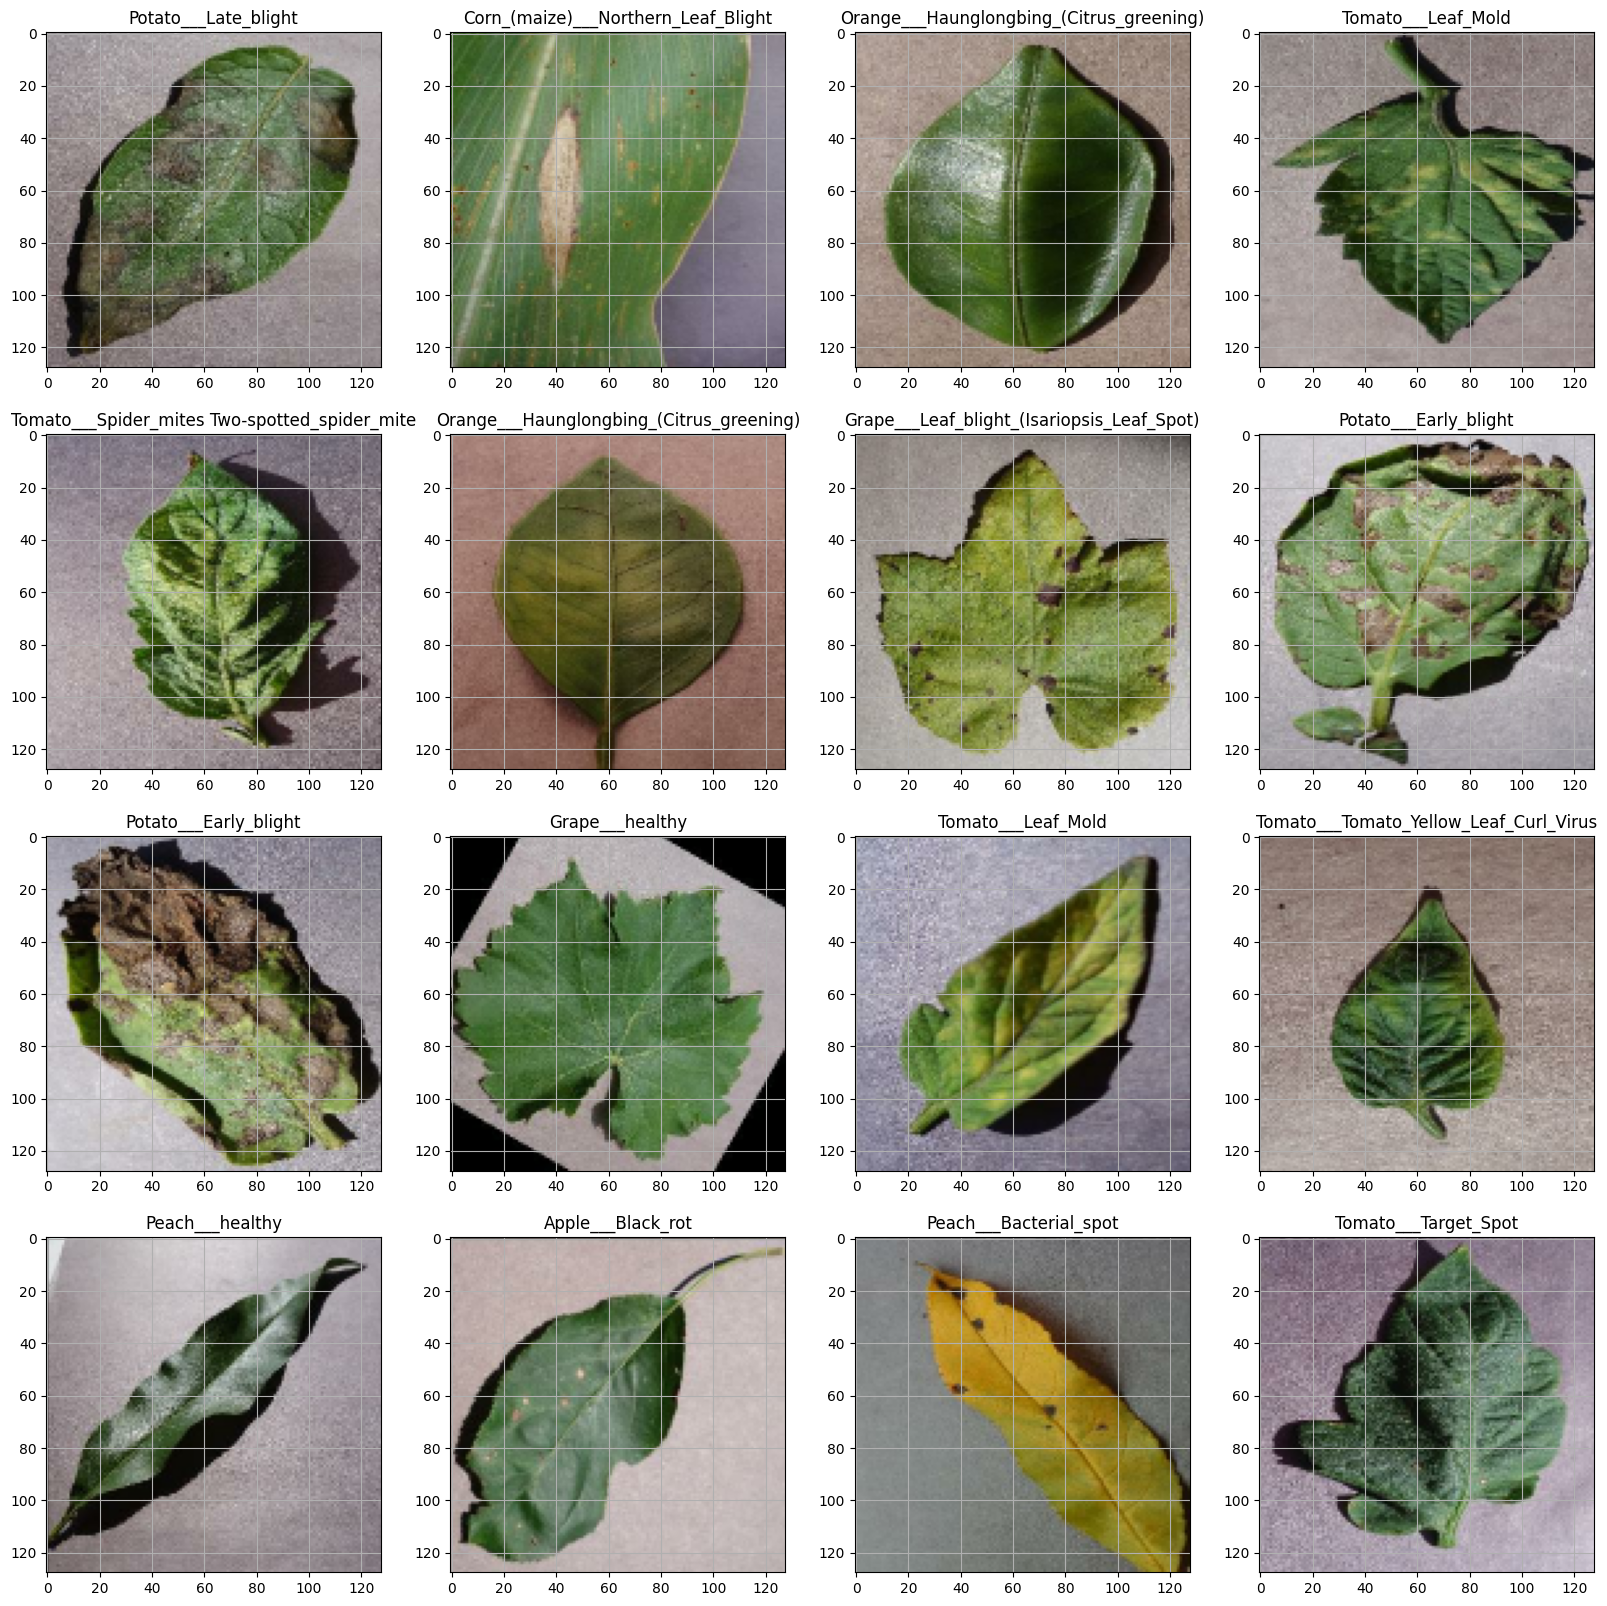

In [45]:
dataset_path = '/content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)'

# Let's display some images from the training set
disease_classes = os.listdir(os.path.join(dataset_path, 'train'))
classes = list(class_indices_training.keys())
plt.figure(figsize=(20, 20))
for X_batch, y_batch in training_set:
    # Create a grid of 4x4 images
    for i in range(0, 16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(X_batch[i].numpy().astype("uint8"))
        plt.title(classes[np.where(y_batch[i] == 1)[0][0]])  # When y is categorical
        # plt.title(classes[int(y_batch[i])])  # When y is binary or sparse
        plt.grid(None)
    # Show the plot
    plt.show()
    break

In [46]:
class_indices_validation = {class_name: idx for idx, class_name in enumerate(validation_set.class_names)}
print(class_indices_validation)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [48]:
!pip install pillow

from PIL import Image
from glob import glob
from concurrent.futures import ThreadPoolExecutor
import os

train_path = '/content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train'
image_paths = glob(f"{train_path}/**/*", recursive=True)

corrupted = []

def check_image(file):
    try:
        img = Image.open(file)
        img.verify()
    except:
        return file
    return None

with ThreadPoolExecutor(max_workers=8) as executor:
    results = executor.map(check_image, image_paths)

corrupted = [file for file in results if file is not None]

print(f"Corrupted Images: {len(corrupted)}")


Corrupted Images: 38


In [49]:
import hashlib
import os
from glob import glob
from concurrent.futures import ThreadPoolExecutor

train_path = '/content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train'
image_paths = glob(f"{train_path}/**/*", recursive=True)

hash_dict = {}
duplicates = []

def compute_hash_and_check(file):
    try:
        with open(file, 'rb') as f:
            img_data = f.read()
        img_hash = hashlib.md5(img_data).hexdigest()
        return (img_hash, file)
    except:
        return (None, file)

with ThreadPoolExecutor(max_workers=8) as executor:
    results = executor.map(compute_hash_and_check, image_paths)

for img_hash, file in results:
    if img_hash is None:
        continue
    if img_hash in hash_dict:
        duplicates.append(file)
    else:
        hash_dict[img_hash] = file

print(f"Number of Duplicate Images: {len(duplicates)}")


Number of Duplicate Images: 18


## Building Model

In [50]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [51]:
model = Sequential()

### Building Convolution Layer

In [52]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [54]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [55]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [56]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [57]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [58]:
model.add(Flatten())

In [59]:
model.add(Dense(units=1500,activation='relu'))

In [60]:
model.add(Dropout(0.4))

In [61]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model

In [62]:
import tensorflow as tf

model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [63]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [64]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 155s 67ms/step - accuracy: 0.3779 - loss: 2.2297 - val_accuracy: 0.8256 - val_loss: 0.5420
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 136s 62ms/step - accuracy: 0.8352 - loss: 0.5282 - val_accuracy: 0.9185 - val_loss: 0.2591
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 0.9068 - loss: 0.2920 - val_accuracy: 0.9289 - val_loss: 0.2288
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 136s 62ms/step - accuracy: 0.9363 - loss: 0.1973 - val_accuracy: 0.9328 - val_loss: 0.2067
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 136s 62ms/step - accuracy: 0.9522 - loss: 0.1487 - val_accuracy: 0.9453 - val_loss: 0.1723
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 135s 61ms/step - accuracy: 0.9627 - loss: 0.1113 - val_accuracy: 0.9607 - val_loss: 0.1238
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 143s 65ms/step - accuracy: 0.9686 - loss: 0.0955 - val_accuracy: 0.9622 - val_loss: 0.1218
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 134s 61ms/step - accuracy: 

## Model Evaluation

In [65]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9898 - loss: 0.0301


In [66]:
print(train_loss,train_acc)

0.02780306711792946 0.9909951090812683


In [67]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9620 - loss: 0.1305


In [68]:
print(val_loss,val_acc)

0.12587283551692963 0.9650580286979675


### Saving Model

In [69]:
model.save("trained_model.keras")

In [70]:
training_history.history

{'accuracy': [0.5846646428108215,
  0.8598762154579163,
  0.9145458340644836,
  0.9407781362533569,
  0.9547478556632996,
  0.9657585620880127,
  0.9713777899742126,
  0.975986897945404,
  0.9801977276802063,
  0.9819048047065735],
 'loss': [1.418550729751587,
  0.4440182149410248,
  0.26320791244506836,
  0.18129369616508484,
  0.13733908534049988,
  0.10299262404441833,
  0.08790403604507446,
  0.07395733892917633,
  0.06109496206045151,
  0.05582785606384277],
 'val_accuracy': [0.8255747556686401,
  0.9185067415237427,
  0.9289209842681885,
  0.9328477382659912,
  0.9452537894248962,
  0.9607329964637756,
  0.9622126221656799,
  0.9644320607185364,
  0.9623833298683167,
  0.9650580286979675],
 'val_loss': [0.5419666767120361,
  0.25907421112060547,
  0.22877797484397888,
  0.20666226744651794,
  0.17233426868915558,
  0.12381671369075775,
  0.12178666889667511,
  0.11187101900577545,
  0.12573659420013428,
  0.12587277591228485]}

In [71]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [72]:
training_history.history['val_accuracy']

[0.8255747556686401,
 0.9185067415237427,
 0.9289209842681885,
 0.9328477382659912,
 0.9452537894248962,
 0.9607329964637756,
 0.9622126221656799,
 0.9644320607185364,
 0.9623833298683167,
 0.9650580286979675]

### Accuracy Visualization

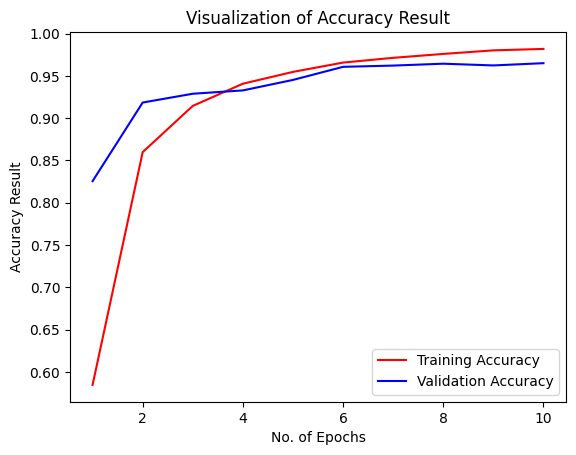

In [73]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [74]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [76]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/Plant_Disease_Dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [77]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step


(array([[9.99374688e-01, 6.19259779e-04, 2.62720024e-09, ...,
         2.97081939e-13, 8.18672560e-12, 4.35604677e-12],
        [9.86329019e-01, 1.36480462e-02, 6.89288839e-08, ...,
         1.74835168e-12, 2.06102201e-11, 8.37248326e-11],
        [9.99999642e-01, 8.42903436e-09, 6.25736796e-10, ...,
         5.46962361e-17, 2.24807440e-14, 2.17465065e-12],
        ...,
        [2.38920754e-12, 3.18961628e-15, 1.06554536e-10, ...,
         7.90516453e-15, 1.99056876e-13, 1.00000000e+00],
        [9.13985207e-12, 9.13161402e-15, 2.07518291e-11, ...,
         5.24322990e-13, 9.91341666e-13, 1.00000000e+00],
        [1.00938901e-11, 2.43920498e-13, 2.93311313e-11, ...,
         2.24618406e-13, 5.01115711e-11, 9.99997139e-01]], dtype=float32),
 (17572, 38))

In [78]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [79]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [80]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [81]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [82]:
from sklearn.metrics import classification_report,confusion_matrix

In [83]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.97      0.97       504
                                 Apple___Black_rot       0.98      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.98      0.97      0.98       440
                                   Apple___healthy       0.98      0.91      0.95       502
                               Blueberry___healthy       0.92      0.98      0.95       454
          Cherry_(including_sour)___Powdery_mildew       0.95      0.98      0.97       421
                 Cherry_(including_sour)___healthy       0.98      0.99      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.91      0.94       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.98      0.

In [84]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[490,   4,   0, ...,   0,   0,   0],
       [  1, 491,   0, ...,   0,   0,   0],
       [  0,   0, 428, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 489,   0,   0],
       [  0,   0,   0, ...,   0, 444,   0],
       [  1,   0,   0, ...,   0,   0, 465]])

### Confusion Matrix Visualization

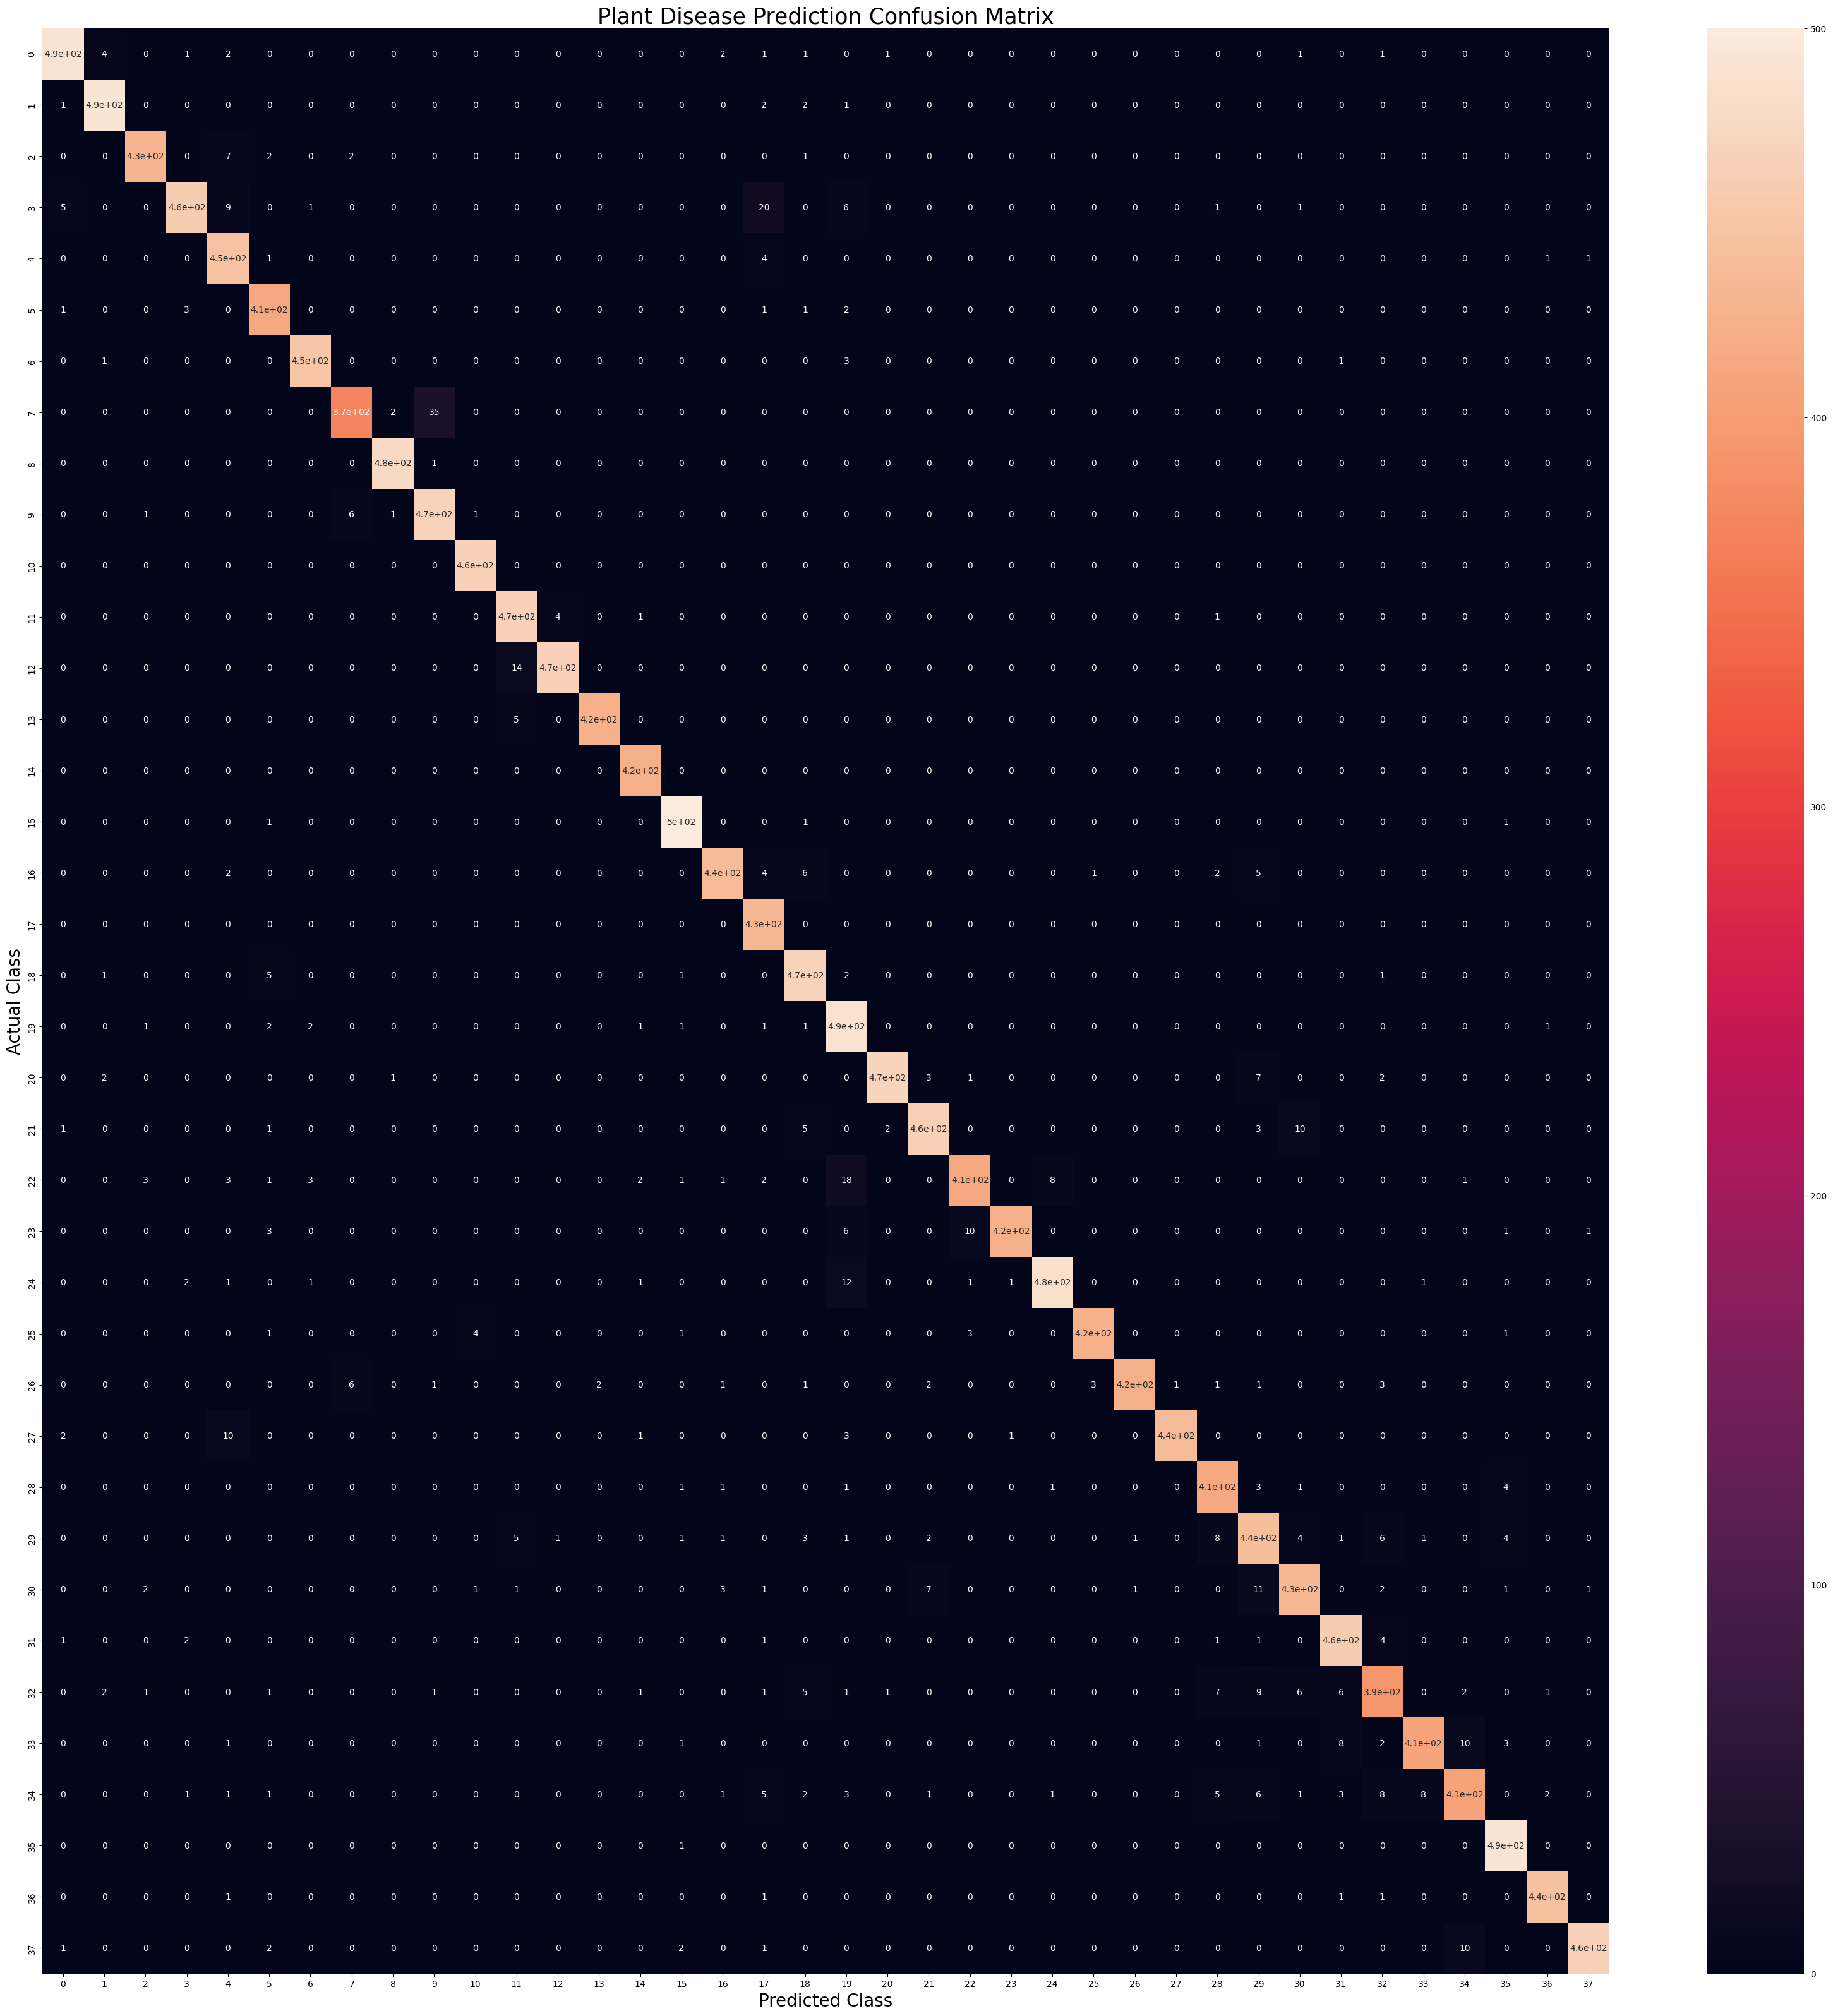

In [85]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()

In [87]:
from google.colab import files
files.download('trained_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>